Tukaj bo izvajane vse analize in filtrirane kode za vzorce, ki jih iščemo; medtem pa bo pr.py bil pomozna knjiznica za osnove funkcije kot so nalaganje tsv-jev in šiščenje podatkovnih zbirk.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from data_utils import *
import sklearn

Koliko obnovljive energije uporabljajo po državah skozi desetletje do zdaj (heatmap prikaz)


Loaded estat_nrg_ind_ren in 0.021s - 3759 rows


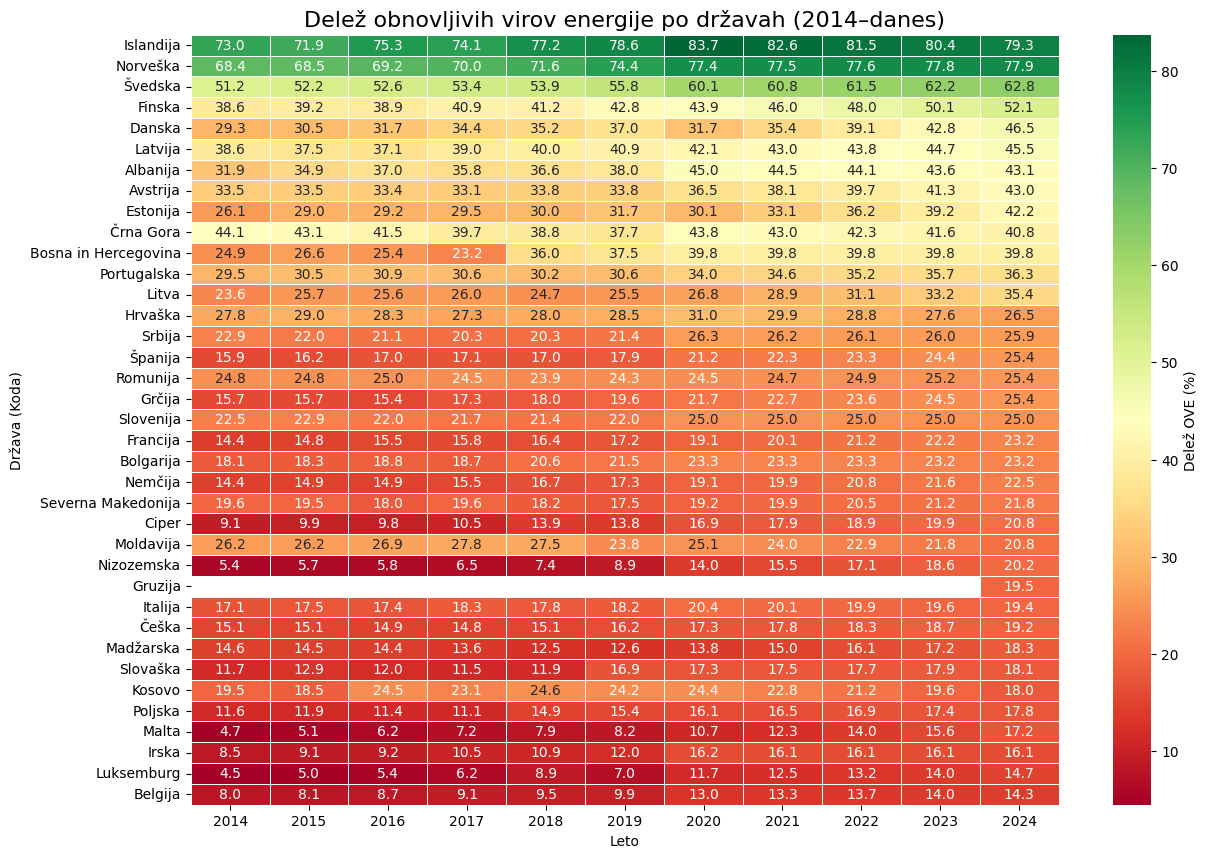

In [2]:
df_ren = share_of_renewables()
df_ren = add_country_names(df_ren)

df_filtered = df_ren[
    (df_ren['nrg_bal'] == 'REN') & 
    (df_ren['year'] >= 2014) &
    (df_ren['geo'].str.len() == 2)
]

pivot_df = df_filtered[df_filtered['nrg_bal'] == 'REN'].pivot(index='drzava', columns='year', values='value')
pivot_df = pivot_df.interpolate(axis=1)
pivot_df = pivot_df.sort_values(by=pivot_df.columns[-1], ascending=False)

plt.figure(figsize=(14, 10))
sns.heatmap(pivot_df, 
            annot=True,
            fmt=".1f",
            cmap="RdYlGn",
            linewidths=.5, 
            cbar_kws={'label': 'Delež OVE (%)'})

plt.title('Delež obnovljivih virov energije po državah (2014–danes)', fontsize=16)
plt.xlabel('Leto')
plt.ylabel('Država (Koda)')
plt.show()


Preskoči Gruzija: Ni dovolj podatkov.


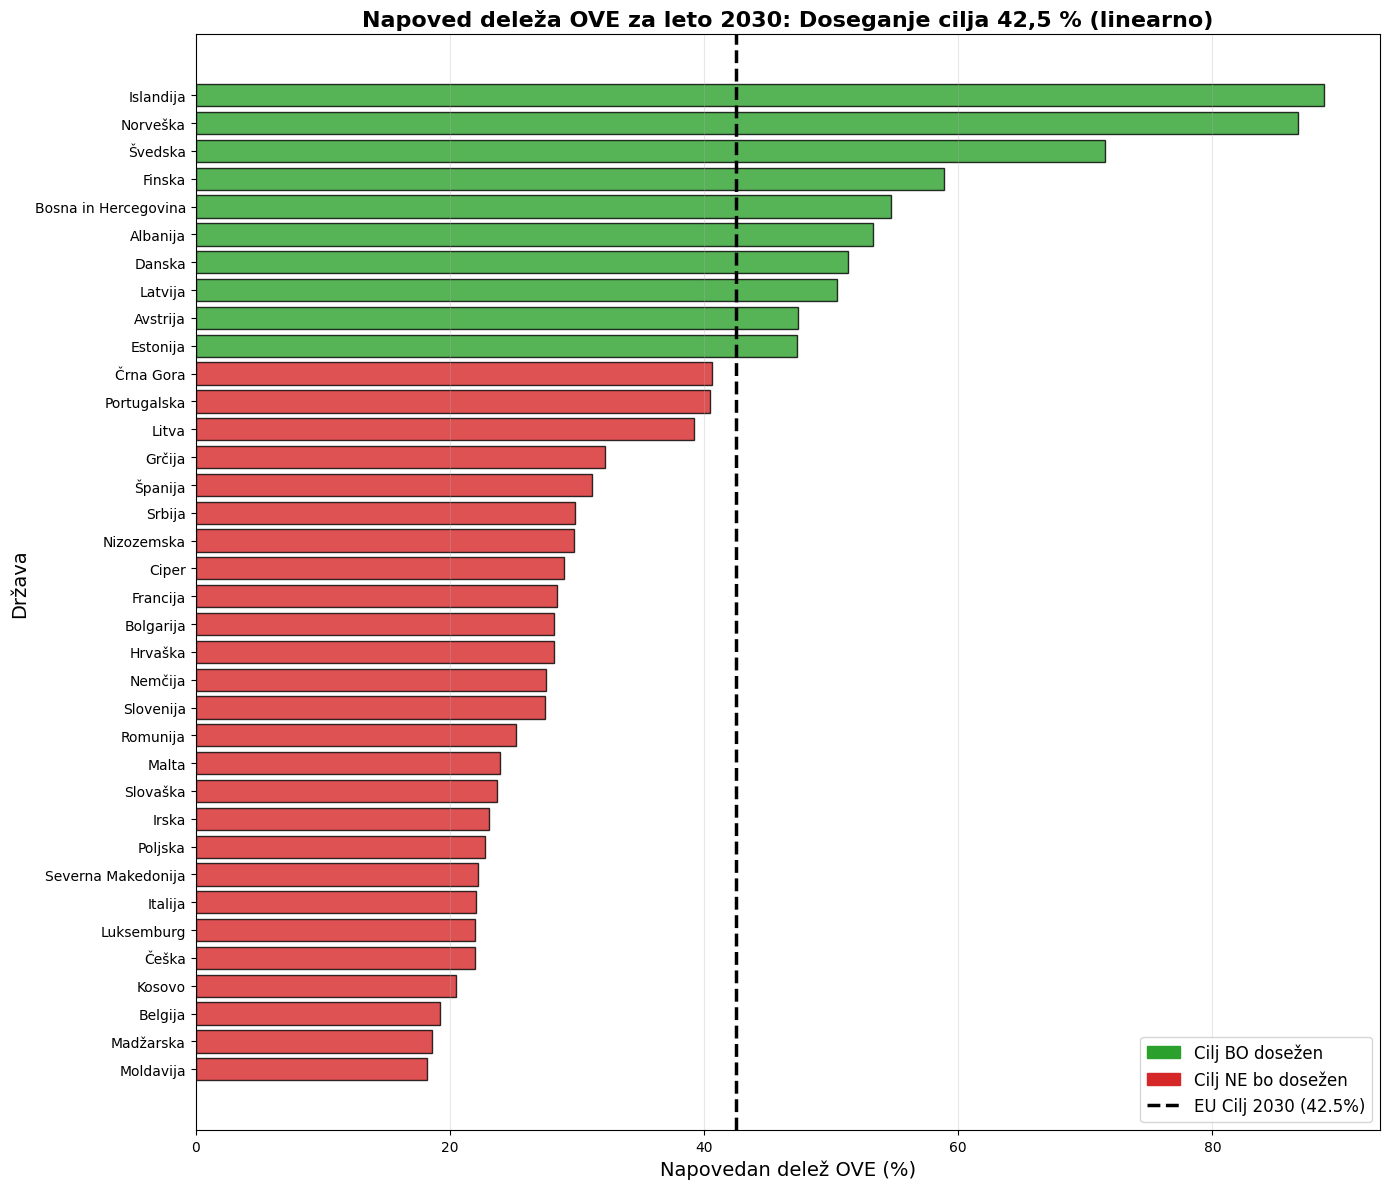

                  drzava  zadnje_leto  napoved_2030  dosega_cilj
0              Islandija       79.332     88.743191         True
1               Norveška       77.932     86.730155         True
2                Švedska       62.846     71.548891         True
3                 Finska       52.124     58.913336         True
10  Bosna in Hercegovina       39.835     54.700400         True
6               Albanija       43.111     53.320364         True
4                 Danska       46.461     51.316100         True
5                Latvija       45.535     50.456264         True
7               Avstrija       42.951     47.381464         True
8               Estonija       42.232     47.327000         True
9              Črna Gora       40.822     40.641945        False
11           Portugalska       36.319     40.501018        False
12                 Litva       35.408     39.212373        False
17                Grčija       25.364     32.196582        False
15               Španija 

In [3]:
from sklearn.linear_model import LinearRegression
import matplotlib.patches as mpatches

results = []

for country in pivot_df.index:
    temp_series = pivot_df.loc[country].dropna()
    if len(temp_series) < 2:
        print(f"Preskoči {country}: Ni dovolj podatkov.")
        continue
        
    y = temp_series.values
    X = np.array(temp_series.index).reshape(-1, 1)
    
    model = LinearRegression()
    model.fit(X, y)
    pred_2030 = model.predict([[2030]])[0]
    
    results.append({
        'drzava': country, 
        'zadnje_leto': y[-1], 
        'napoved_2030': pred_2030
    })


df_pred = pd.DataFrame(results)
df_pred['dosega_cilj'] = df_pred['napoved_2030'] >= 42.5
df_pred = df_pred.sort_values(by='napoved_2030', ascending=False)
df_viz = df_pred.sort_values(by='napoved_2030', ascending=True)

colors = ['#2ca02c' if x else '#d62728' for x in df_viz['dosega_cilj']]

plt.figure(figsize=(14, 12))

bars = plt.barh(df_viz['drzava'], df_viz['napoved_2030'], color=colors, edgecolor='black', alpha=0.8)

plt.axvline(x=42.5, color='black', linestyle='--', linewidth=2.5, label='EU Cilj 2030 (42.5%)')
plt.title('Napoved deleža OVE za leto 2030: Doseganje cilja 42,5 % (linearno)', fontsize=16, fontweight='bold')
plt.xlabel('Napovedan delež OVE (%)', fontsize=14)
plt.ylabel('Država', fontsize=14)
plt.grid(axis='x', linestyle='-', alpha=0.3)

red_patch = mpatches.Patch(color='#d62728', label='Cilj NE bo dosežen')
green_patch = mpatches.Patch(color='#2ca02c', label='Cilj BO dosežen')
plt.legend(handles=[green_patch, red_patch, plt.gca().get_lines()[0]], loc='lower right', fontsize=12)

plt.tight_layout()
plt.show()

print(df_pred[['drzava', 'zadnje_leto', 'napoved_2030', 'dosega_cilj']])

Za izboljšanje napovedi smo namesto linearne regresije uporablili polinomsko regresijo (2. stopnje) ter regulirali z Ridge regresijo (α = 1).

Preskoči Gruzija: Ni dovolj podatkov.


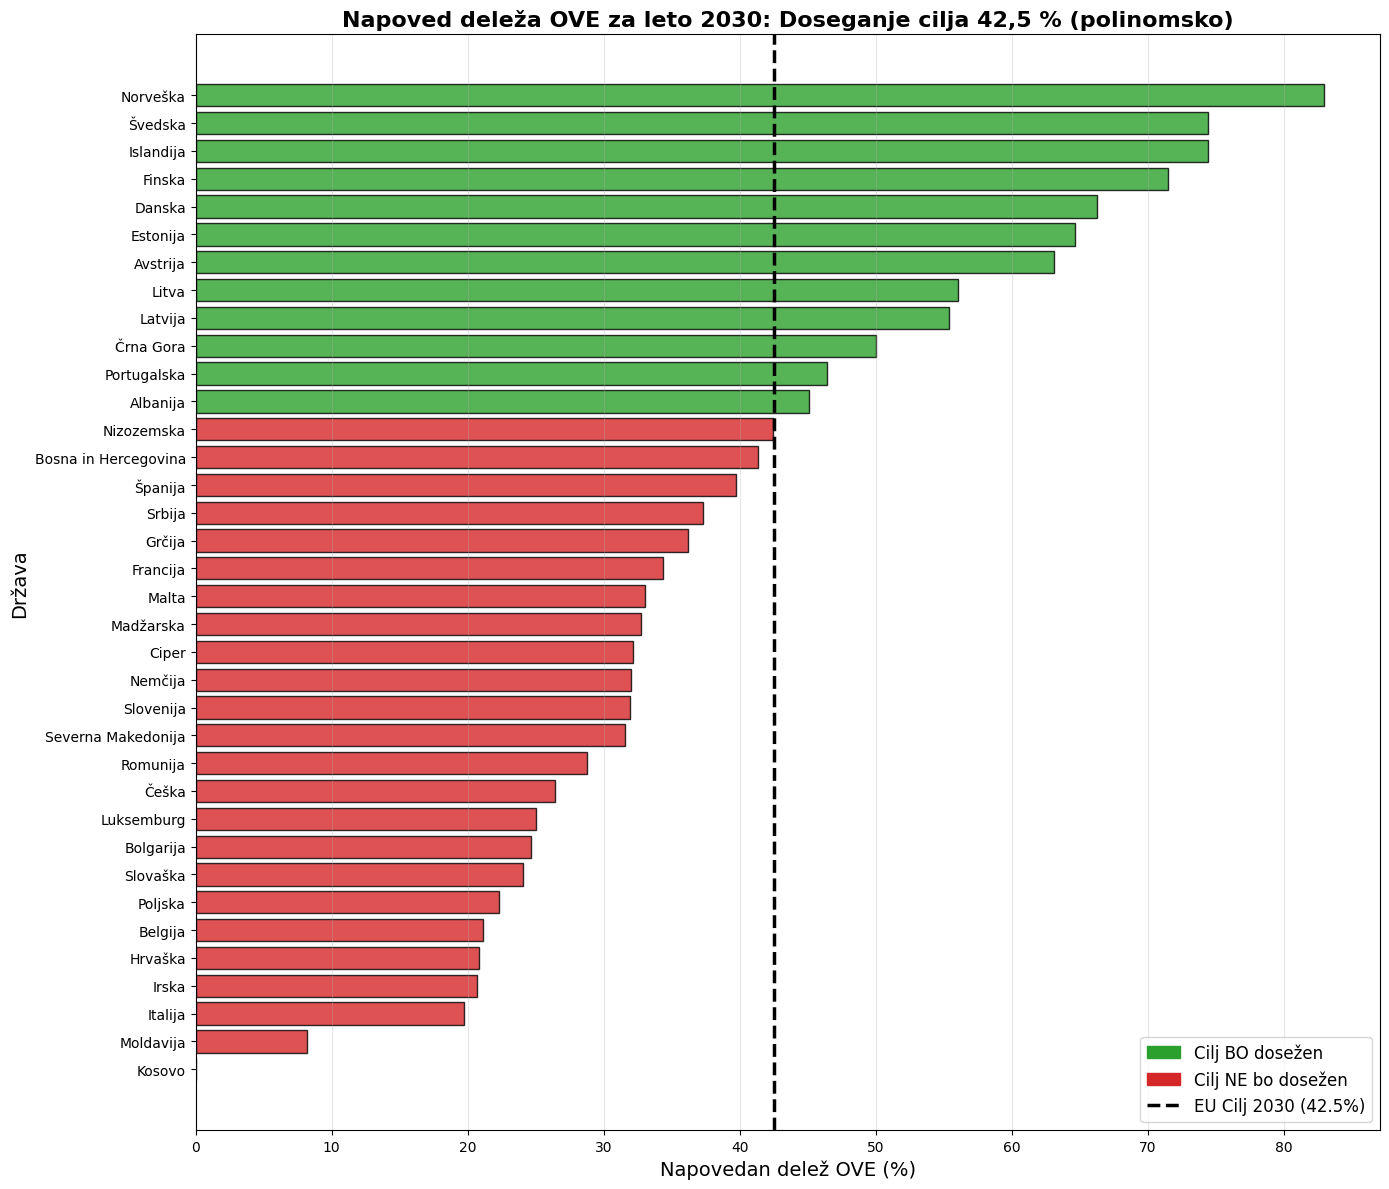

                  drzava  zadnje_leto  napoved_2030  dosega_cilj
1               Norveška       77.932     82.913228         True
2                Švedska       62.846     74.451638         True
0              Islandija       79.332     74.403057         True
3                 Finska       52.124     71.471552         True
4                 Danska       46.461     66.238399         True
8               Estonija       42.232     64.612659         True
7               Avstrija       42.951     63.086561         True
12                 Litva       35.408     56.026998         True
5                Latvija       45.535     55.355286         True
9              Črna Gora       40.822     50.034294         True
11           Portugalska       36.319     46.400727         True
6               Albanija       43.111     45.054818         True
25            Nizozemska       20.180     42.460319        False
10  Bosna in Hercegovina       39.835     41.371860        False
15               Španija 

In [4]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
import matplotlib.patches as mpatches

rezultati = []

for country in pivot_df.index:
    temp_series = pivot_df.loc[country].dropna()
    if len(temp_series) < 2:
        print(f"Preskoči {country}: Ni dovolj podatkov.")
        continue
        
    # Priprava podatkov za polinomsko regresijo
    y = temp_series.values
    zacetek = np.array(temp_series.index).min()
    X = (np.array(temp_series.index) - zacetek).reshape(-1, 1)

    # Uporaba polinomske regresije
    polinom = PolynomialFeatures(degree=2)
    X_polinom = polinom.fit_transform(X)

    # Uporaba Ridge regresije za stabilnost modela
    model = Ridge(alpha=1.0)
    model.fit(X_polinom, y)

    # Napoved za leto 2030
    pred_2030 = model.predict(polinom.transform([[2030 - zacetek]]))[0]
    pred_2030 = np.clip(pred_2030, 0, 100)

    rezultati.append({
        'drzava': country,
        'zadnje_leto': y[-1],
        'napoved_2030': pred_2030
    })


df_pred = pd.DataFrame(rezultati)
df_pred['dosega_cilj'] = df_pred['napoved_2030'] >= 42.5
df_pred = df_pred.sort_values(by='napoved_2030', ascending=False)
df_viz = df_pred.sort_values(by='napoved_2030', ascending=True)

colors = ['#2ca02c' if x else '#d62728' for x in df_viz['dosega_cilj']]

plt.figure(figsize=(14, 12))

bars = plt.barh(df_viz['drzava'], df_viz['napoved_2030'], color=colors, edgecolor='black', alpha=0.8)

plt.axvline(x=42.5, color='black', linestyle='--', linewidth=2.5, label='EU Cilj 2030 (42.5%)')
plt.title('Napoved deleža OVE za leto 2030: Doseganje cilja 42,5 % (polinomsko)', fontsize=16, fontweight='bold')
plt.xlabel('Napovedan delež OVE (%)', fontsize=14)
plt.ylabel('Država', fontsize=14)
plt.grid(axis='x', linestyle='-', alpha=0.3)

red_patch = mpatches.Patch(color='#d62728', label='Cilj NE bo dosežen')
green_patch = mpatches.Patch(color='#2ca02c', label='Cilj BO dosežen')
plt.legend(handles=[green_patch, red_patch, plt.gca().get_lines()[0]], loc='lower right', fontsize=12)

plt.tight_layout()
plt.show()


print(df_pred[['drzava', 'zadnje_leto', 'napoved_2030', 'dosega_cilj']])

Za bolj podrobno analizo bomo uporabili sestavljeno letno stopnjo rasti, saj ta upošteva učinek obresti.

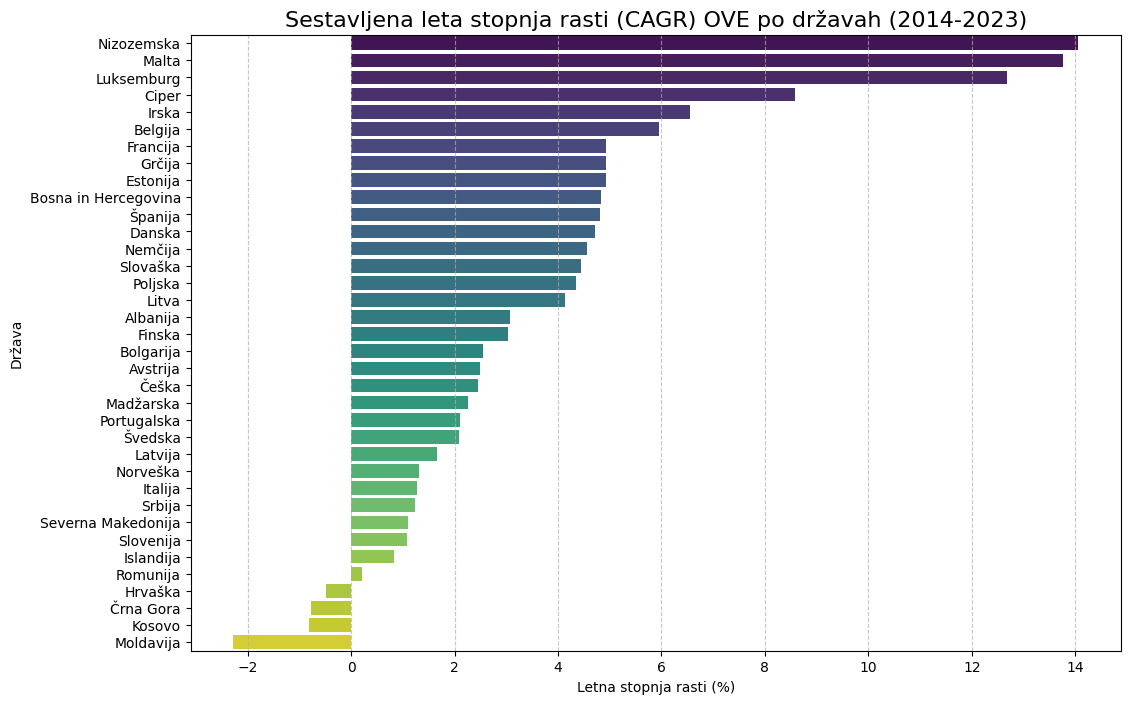

drzava
Nizozemska              14.059712
Malta                   13.753199
Luksemburg              12.671785
Ciper                    8.588663
Irska                    6.552049
Belgija                  5.956596
Francija                 4.925624
Grčija                   4.924972
Estonija                 4.918053
Bosna in Hercegovina     4.822295
Španija                  4.816611
Danska                   4.714609
Nemčija                  4.565671
Slovaška                 4.443603
Poljska                  4.352829
Litva                    4.143858
Albanija                 3.071758
Finska                   3.040494
Bolgarija                2.546252
Avstrija                 2.500994
Češka                    2.454761
Madžarska                2.251760
Portugalska              2.098512
Švedska                  2.080397
Latvija                  1.658381
Norveška                 1.312297
Italija                  1.272775
Srbija                   1.239733
Severna Makedonija       1.095749
Sloveni

In [5]:
def izracun_cagr(df_pivot):
    # cagr Izračunamo na podlagi prvega in zadnjega leta v pivot tabeli
    df_prvo = df_pivot.columns[0]
    df_zadnje = df_pivot.columns[-1]
    n_let = df_zadnje - df_prvo

    cagr = ((df_pivot[df_zadnje] /df_pivot[df_prvo])** (1/n_let) - 1)
    return cagr *100

#CAGR za vse države
cagr_s = izracun_cagr(pivot_df).sort_values(ascending=False)
# Odstranimo Gruzijo, premalo podatkov
cagr_s = cagr_s[cagr_s.index != 'Gruzija']

#Vizualizacija 
plt.figure(figsize=(12, 8))
cagr_df = cagr_s.reset_index()
cagr_df.columns = ['drzava', 'CAGR']
sns.barplot(data=cagr_df, x='CAGR', y='drzava', hue='drzava', dodge=False, palette='viridis', legend=False)
plt.title("Sestavljena leta stopnja rasti (CAGR) OVE po državah (2014-2023)", fontsize=16)
plt.xlabel("Letna stopnja rasti (%)")
plt.ylabel("Država")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print(cagr_s)

Ugotoviti želimo ali imajo bogatejše države kakšno prednost pred revnejšimi in si lahko tako privoščijo hitrejši prehod.

Loaded sdg_08_10_tabular in 0.013s - 2106 rows


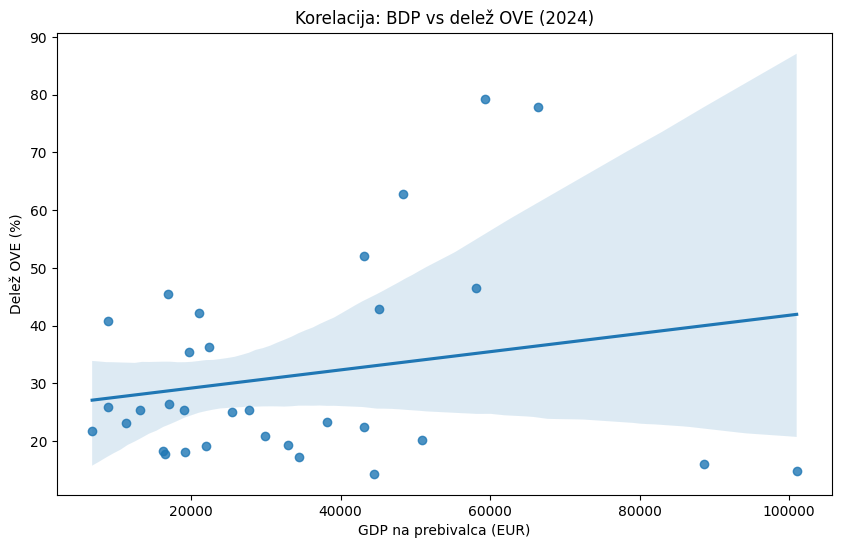

Pearsonov korelacijski koeficient: 0.21


In [6]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Uvoz in dodajanje imen
df_gdp_raw = load_tsv("sdg_08_10_tabular", "data")
df_gdp = add_country_names(df_gdp_raw)

zadnje_leto = pivot_df.columns[-1]


df_gdp_fix = df_gdp[
    (df_gdp["unit"].str.contains("CLV", na=False)) & 
    (df_gdp["unit"].str.contains("EUR_HAB", na=False)) &
    (df_gdp["year"] == zadnje_leto) & 
    (df_gdp["value"] > 1000)
].copy()

#Združevanje
analiza_df = pd.DataFrame({
    "OVE_delez": pivot_df[zadnje_leto],
    "CAGR": cagr_s
}).merge(df_gdp_fix[['drzava', 'value']], left_index=True, right_on='drzava')

analiza_df.rename(columns={'value': 'GDP_per_capita'}, inplace=True)

# ćiščenje praznih vrednosti
analiza_clean = analiza_df.copy()
analiza_clean['GDP_per_capita'] = pd.to_numeric(analiza_clean['GDP_per_capita'], errors='coerce')
analiza_clean['OVE_delez'] = pd.to_numeric(analiza_clean['OVE_delez'], errors='coerce')

# odstranimo vrednosti kjer ni obeh podatkov
analiza_clean = analiza_clean.dropna(subset=['GDP_per_capita', 'OVE_delez'])

#Regresija
if not analiza_clean.empty:
    X = analiza_clean[['GDP_per_capita']].values
    y = analiza_clean['OVE_delez'].values
    
    model = LinearRegression().fit(X, y)
    analiza_clean["ostanek"] = y - model.predict(X)
    
    
    plt.figure(figsize=(10, 6))
    sns.regplot(data=analiza_clean, x="GDP_per_capita", y="OVE_delez")
    plt.title(f"Korelacija: BDP vs delež OVE ({zadnje_leto})")
    plt.xlabel("GDP na prebivalca (EUR)")
    plt.ylabel("Delež OVE (%)")
    plt.show()
    
    
    korelacija = analiza_clean['GDP_per_capita'].corr(analiza_clean['OVE_delez'])
    print(f"Pearsonov korelacijski koeficient: {korelacija:.2f}")



najti moramo države ki najbolj izstopajo iz povprečja, torej imajo ali zelo visok OVE in nizek BDP ali pa obratno


In [7]:
from sklearn.linear_model import LinearRegression

analiza_clean = analiza_df.dropna(subset=['GDP_per_capita', 'OVE_delez']).copy()

X = analiza_clean[['GDP_per_capita']].values
y = analiza_clean['OVE_delez'].values

model = LinearRegression().fit(X,y)
napoved = model.predict(X)
analiza_clean['ostanek'] = y- napoved

#top 3 odkloni gor in dol
pozitivni_odkl = analiza_clean.sort_values(by='ostanek', ascending=False).head(3)
negativni_odkl = analiza_clean.sort_values(by='ostanek', ascending=True).head(3)

print("Države ki presegajo pričakkovana glede na BDP:")
print(pozitivni_odkl[["drzava", "OVE_delez", "GDP_per_capita"]])

print("\nDržave ki zaostajajo glede na BDP:")
print(negativni_odkl[["drzava", "OVE_delez", "GDP_per_capita"]])

Države ki presegajo pričakkovana glede na BDP:
         drzava  OVE_delez  GDP_per_capita
1966  Islandija     79.332         59270.0
1975   Norveška     77.932         66460.0
1980    Švedska     62.846         48310.0

Države ki zaostajajo glede na BDP:
          drzava  OVE_delez  GDP_per_capita
1969  Luksemburg     14.742        101000.0
1965       Irska     16.064         88600.0
1947     Belgija     14.336         44440.0


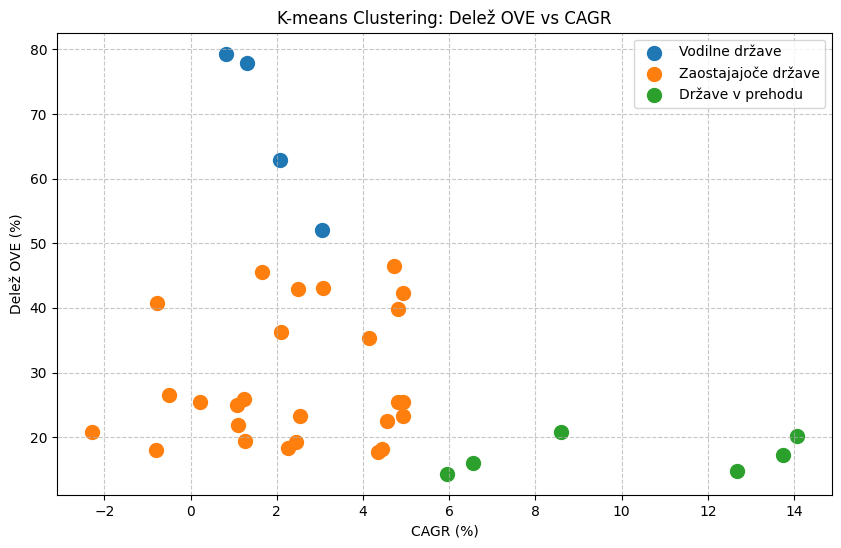


Povprečne vrednosti OVE in CAGR po clusterjih:

Vodilne države:
  Povprečen OVE: 68.06%
  Povprečen CAGR: 1.82%
  Države: ['Islandija', 'Norveška', 'Švedska', 'Finska']

Zaostajajoče države:
  Povprečen OVE: 28.78%
  Povprečen CAGR: 2.45%
  Države: ['Danska', 'Latvija', 'Albanija', 'Avstrija', 'Estonija', 'Črna Gora', 'Bosna in Hercegovina', 'Portugalska', 'Litva', 'Hrvaška', 'Srbija', 'Španija', 'Romunija', 'Grčija', 'Slovenija', 'Francija', 'Bolgarija', 'Nemčija', 'Severna Makedonija', 'Moldavija', 'Italija', 'Češka', 'Madžarska', 'Slovaška', 'Kosovo', 'Poljska']

Države v prehodu:
  Povprečen OVE: 17.23%
  Povprečen CAGR: 10.26%
  Države: ['Ciper', 'Nizozemska', 'Malta', 'Irska', 'Luksemburg', 'Belgija']


In [8]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Izračun CAGR za vse države
cagr_s = izracun_cagr(pivot_df)

# Priprava podatkov za clustering
df_cluster = pd.DataFrame({
    'drzava': pivot_df.index,
    'OVE': pivot_df.iloc[:, -1],
    'CAGR': cagr_s
}).dropna()



# Standardizacija podatkov
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[['OVE', 'CAGR']])

# K-means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df_cluster['cluster'] = kmeans.fit_predict(X_scaled)

# Povzetek po clusterjih
cluster_summary = df_cluster.groupby('cluster')[['OVE', 'CAGR']].mean().sort_index()

# Dodelitev imen clusterjem
cluster_imena = {
    2: 'Vodilne države',
    1: 'Države v prehodu',
    0: 'Zaostajajoče države'
}

df_cluster['ime_skupine'] = df_cluster['cluster'].map(cluster_imena)


#Vizualizacija clusterjev

plt.figure(figsize=(10, 6))

for ime in df_cluster['ime_skupine'].unique():
    subset = df_cluster[df_cluster['ime_skupine'] == ime]
    plt.scatter(subset['CAGR'], subset['OVE'], label=ime, s=100)

plt.title('K-means Clustering: Delež OVE vs CAGR')
plt.xlabel('CAGR (%)')
plt.ylabel('Delež OVE (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


# Povprečne vrednosti OVE in CAGR po clusterjih
print("\nPovprečne vrednosti OVE in CAGR po clusterjih:")

for name in df_cluster['ime_skupine'].unique():
    subset = df_cluster[df_cluster['ime_skupine'] == name]
    
    mean_ove = subset['OVE'].mean()
    mean_cagr = subset['CAGR'].mean()
    
    print(f"\n{name}:")
    print(f"  Povprečen OVE: {mean_ove:.2f}%")
    print(f"  Povprečen CAGR: {mean_cagr:.2f}%")
    print(f"  Države: {subset['drzava'].tolist()}")
    

### Analiza izvoza fosilnih goriv in njegova povezava z visokim deležem OVE

Preučujemo hipotezo lažjega financiranja zelenega prehoda držav, katerih prihodki izvoza fosilnih goriv lahko financirajo naložbe v OVE.

In [9]:
df_bal = load_tsv('estat_nrg_bal_s', 'data')
df_bal = add_country_names(df_bal)

# Fosilna goriva: zemeljski plin (G3000), nafta in naftni derivati (O4000XBIO), trdna fosilna goriva/premog (C0000X0350-0370)
FOSSIL_SIECS = {
    'G3000': 'Zemeljski plin',
    'O4000XBIO': 'Nafta in derivati',
    'C0000X0350-0370': 'Premog in trda goriva'
}
df_exp = df_bal[
    (df_bal['nrg_bal'] == 'EXP') &
    (df_bal['siec'].isin(FOSSIL_SIECS.keys())) &
    (df_bal['unit'] == 'TJ') &
    (df_bal['year'] >= 2014) &
    (df_bal['geo'].str.len() == 2)
].copy()

df_prod = df_bal[
    (df_bal['nrg_bal'] == 'PPRD') &
    (df_bal['siec'].isin(FOSSIL_SIECS.keys())) &
    (df_bal['unit'] == 'TJ') &
    (df_bal['year'] >= 2014) &
    (df_bal['geo'].str.len() == 2)
].copy()

# Skupni izvoz fosilnih goriv po državi in letu
exp_total = df_exp.groupby(['geo', 'drzava', 'year'])['value'].sum().reset_index()
exp_total.rename(columns={'value': 'izvoz_TJ'}, inplace=True)

# Skupna domača proizvodnja fosilnih goriv
prod_total = df_prod.groupby(['geo', 'drzava', 'year'])['value'].sum().reset_index()
prod_total.rename(columns={'value': 'proizvodnja_TJ'}, inplace=True)

# Delež izvoza
exp_prod = exp_total.merge(prod_total, on=['geo', 'drzava', 'year'], how='inner')
exp_prod['izvozna_intenzivnost'] = np.where(
    exp_prod['proizvodnja_TJ'] > 0,
    exp_prod['izvoz_TJ'] / exp_prod['proizvodnja_TJ'] * 100,
    np.nan
)

# Povprečje za zadnja razpoložljiva leta (2019-2023)
exp_avg = exp_prod[exp_prod['year'].between(2019, 2023)].groupby(['geo', 'drzava']).agg(
    izvoz_TJ=('izvoz_TJ', 'mean'),
    proizvodnja_TJ=('proizvodnja_TJ', 'mean'),
    izvozna_intenzivnost=('izvozna_intenzivnost', 'mean')
).reset_index()

# Samo države z relevantno proizvodnjo (> 1000 TJ)
exp_avg_filtered = exp_avg[exp_avg['proizvodnja_TJ'] > 1000].copy()

print(f'Število držav z relevantnimi podatki o izvozu fosilnih goriv: {len(exp_avg_filtered)}')
print(exp_avg_filtered[['drzava', 'izvoz_TJ', 'proizvodnja_TJ', 'izvozna_intenzivnost']]
      .sort_values('izvoz_TJ', ascending=False).to_string(index=False))

Loaded estat_nrg_bal_s in 7.559s - 4712190 rows
Število držav z relevantnimi podatki o izvozu fosilnih goriv: 29
              drzava     izvoz_TJ  proizvodnja_TJ  izvozna_intenzivnost
            Norveška 8002076.0348    8185877.5664             97.745245
          Nizozemska 4955145.3556     693023.4528            801.631777
             Italija 1202715.5080     341216.2370            356.914989
             Španija 1133894.9422       2687.8542          66719.985901
             Nemčija 1076929.4712    1370625.2200             79.187719
            Francija  982458.5350      35637.2324           2774.361833
              Grčija  799985.1396      79688.3720           1107.083673
 Združeno kraljestvo  629938.5416     746889.4540             84.341603
             Poljska  576056.6018    1872808.3914             30.955933
              Danska  435294.8046     217873.5860            212.588972
             Turčija  405503.1678     861818.5786             47.196420
               Litva  3

Na spodnjem grafu vidimo povprečni izvoz fosilnih goriv v EU.

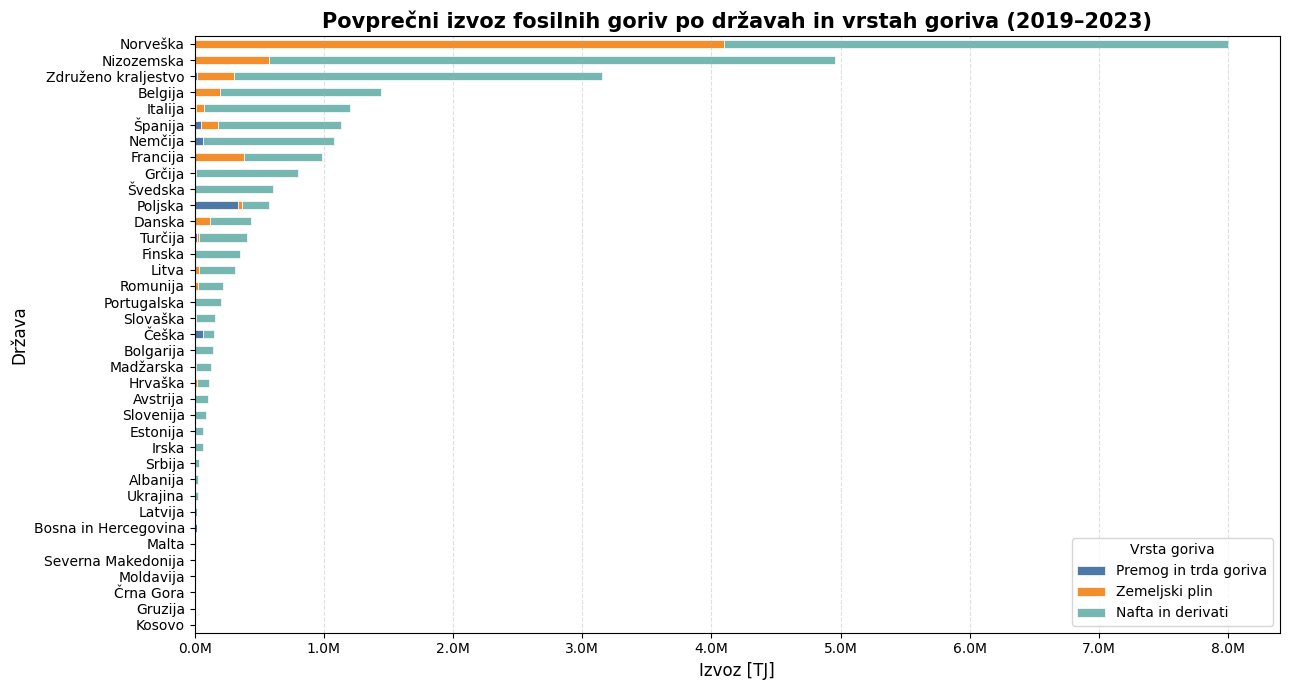

In [10]:
exp_by_type = df_exp[df_exp['year'].between(2019, 2023)].groupby(['drzava', 'siec'])['value'].mean().reset_index()
exp_by_type = exp_by_type[exp_by_type['value'] > 100]

pivot_exp = exp_by_type.pivot(index='drzava', columns='siec', values='value').fillna(0)
pivot_exp.columns = [FOSSIL_SIECS.get(c, c) for c in pivot_exp.columns]
pivot_exp['skupaj'] = pivot_exp.sum(axis=1)
pivot_exp = pivot_exp[pivot_exp['skupaj'] > 1000].sort_values('skupaj', ascending=True)
pivot_exp = pivot_exp.drop(columns='skupaj')

fig, ax = plt.subplots(figsize=(13, 7))
pivot_exp.plot(kind='barh', stacked=True, ax=ax,
               color=['#4e79a7', '#f28e2b', '#76b7b2'], edgecolor='white', linewidth=0.5)

ax.set_title('Povprečni izvoz fosilnih goriv po državah in vrstah goriva (2019–2023)', fontsize=15, fontweight='bold')
ax.set_xlabel('Izvoz [TJ]', fontsize=12)
ax.set_ylabel('Država', fontsize=12)
ax.legend(title='Vrsta goriva', loc='lower right')
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

Na spodnjem grafu vidimo povezavo med izvozom fosilnih goriv in CAGR obnovljivih virov energij, z vrednostjo Pearsonovega koeficienta 0.52. So pa zaradi izbire CAGR, ne pa celotnega deleža obnovljivih virov, nekatere skandinavske države z že velikim deležom nizko na grafu.

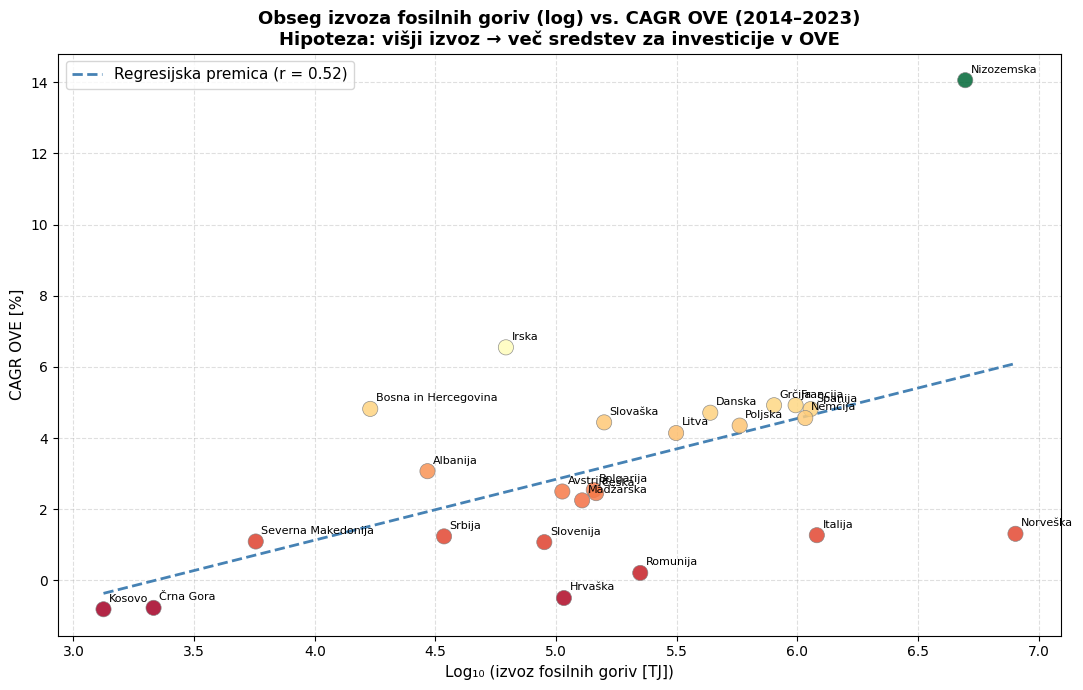

Pearsonov korelacijski koeficient (log izvoz vs CAGR): 0.52


In [11]:
cagr_df2 = cagr_s.reset_index()
cagr_df2.columns = ['drzava', 'CAGR']

hipoteza = cagr_df2.merge(exp_avg_filtered[['drzava', 'izvoz_TJ', 'izvozna_intenzivnost']], on='drzava', how='inner')
hipoteza = hipoteza.dropna()

hipoteza['log_izvoz'] = np.log10(hipoteza['izvoz_TJ'].replace(0, np.nan))
hipoteza = hipoteza.dropna()

X_h2 = hipoteza[['log_izvoz']].values
y_h2 = hipoteza['CAGR'].values
model_h2 = LinearRegression().fit(X_h2, y_h2)
r_h2 = hipoteza['log_izvoz'].corr(hipoteza['CAGR'])

x_line2 = np.linspace(hipoteza['log_izvoz'].min(), hipoteza['log_izvoz'].max(), 100)
y_line2 = model_h2.predict(x_line2.reshape(-1, 1))

fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(hipoteza['log_izvoz'], hipoteza['CAGR'],
           c=hipoteza['CAGR'], cmap='RdYlGn', s=120,
           edgecolors='grey', linewidths=0.5, alpha=0.85, zorder=3)
ax.plot(x_line2, y_line2, color='steelblue', linewidth=2, linestyle='--',
        label=f'Regresijska premica (r = {r_h2:.2f})')

for _, row in hipoteza.iterrows():
    ax.annotate(row['drzava'], (row['log_izvoz'], row['CAGR']),
                fontsize=8, ha='left', va='bottom',
                xytext=(4, 4), textcoords='offset points')

ax.set_title('Obseg izvoza fosilnih goriv (log) vs. CAGR OVE (2014–2023)\n'
             'Hipoteza: višji izvoz → več sredstev za investicije v OVE', fontsize=13, fontweight='bold')
ax.set_xlabel('Log₁₀ (izvoz fosilnih goriv [TJ])', fontsize=11)
ax.set_ylabel('CAGR OVE [%]', fontsize=11)
ax.legend(fontsize=11)
ax.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(f'Pearsonov korelacijski koeficient (log izvoz vs CAGR): {r_h2:.2f}')

Loaded sdg_08_10_tabular in 0.012s - 2106 rows


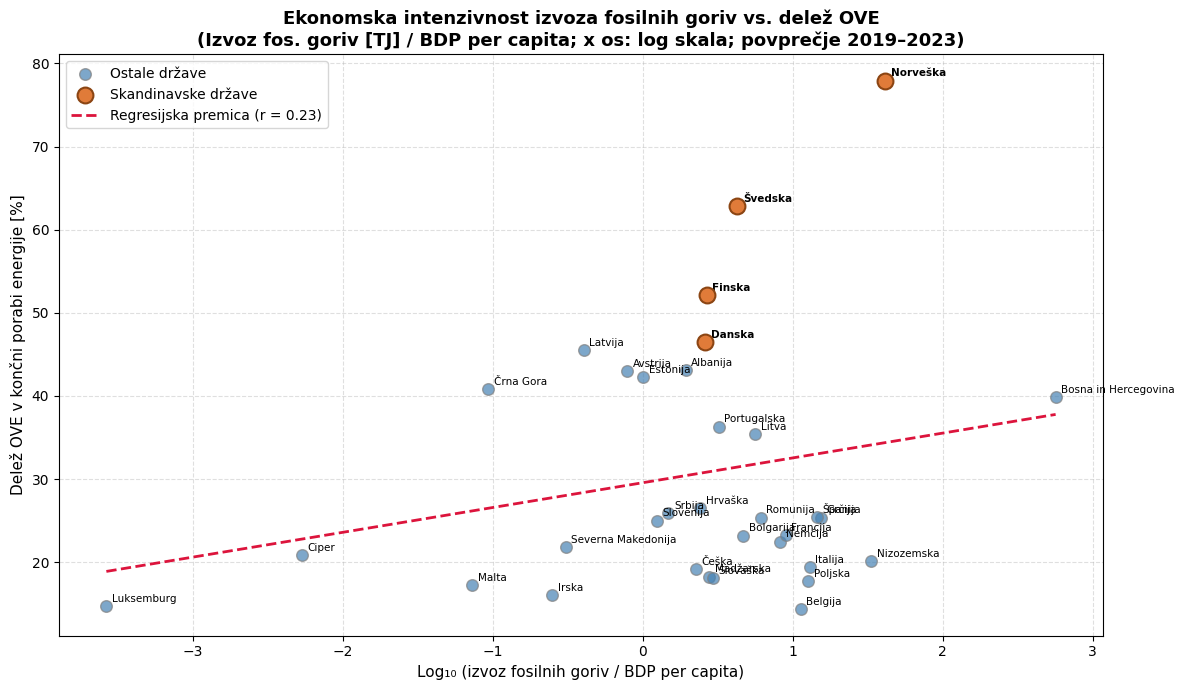

Pearsonov r (log normaliziran izvoz vs OVE delež): 0.23

Top 10 po ekonomski intenzivnosti izvoza fosilnih goriv:
              drzava  izvoz_norm  OVE_delez
Bosna in Hercegovina  565.948100     39.835
            Norveška   41.229113     77.932
          Nizozemska   33.380120     20.180
              Grčija   15.371323     25.364
             Španija   14.515899     25.417
             Italija   12.975957     19.385
             Poljska   12.667823     17.770
             Belgija   11.280961     14.336
            Francija    8.948199     23.229
             Nemčija    8.262970     22.474


In [12]:
df_gdp = load_tsv('sdg_08_10_tabular', 'data')
df_bal_raw = pd.read_csv('data/estat_nrg_bal_s.tsv', sep='\t')
df_bal_raw = clean_eurostat_df(df_bal_raw)
df_res_raw = pd.read_csv('data/estat_nrg_ind_ren.tsv', sep='\t')
df_res_raw = clean_eurostat_df(df_res_raw)
gdp_pc = df_gdp[
    (df_gdp['unit'] == 'CLV20_EUR_HAB') &
    (df_gdp['na_item'] == 'B1GQ') &
    (df_gdp['year'].between(2019, 2023)) &
    (df_gdp['geo'].str.len() == 2)
].groupby('geo')['value'].mean().reset_index()
gdp_pc.columns = ['geo', 'gdp_per_capita']

exp_avg_all = df_bal_raw[
    (df_bal_raw['nrg_bal'] == 'EXP') &
    (df_bal_raw['siec'].isin(['G3000', 'O4000XBIO', 'C0000X0350-0370'])) &
    (df_bal_raw['unit'] == 'TJ') &
    (df_bal_raw['year'].between(2019, 2023)) &
    (df_bal_raw['geo'].str.len() == 2)
].groupby('geo')['value'].mean().reset_index()
exp_avg_all.columns = ['geo', 'izvoz_TJ']

res_latest = df_res_raw[
    (df_res_raw['nrg_bal'] == 'REN') &
    (df_res_raw['unit'] == 'PC') &
    (df_res_raw['geo'].str.len() == 2)
].sort_values('year').groupby('geo').last().reset_index()[['geo', 'value']]
res_latest.columns = ['geo', 'OVE_delez']

scatter_df = exp_avg_all.merge(gdp_pc, on='geo', how='inner')
scatter_df = scatter_df.merge(res_latest, on='geo', how='inner')

scatter_df['izvoz_norm'] = scatter_df['izvoz_TJ'] / scatter_df['gdp_per_capita']
scatter_df = scatter_df[scatter_df['izvoz_norm'] > 0].dropna()

scatter_df['log_izvoz_norm'] = np.log10(scatter_df['izvoz_norm'])

country_map = get_country_mapping()
scatter_df['drzava'] = scatter_df['geo'].map(country_map).fillna(scatter_df['geo'])

SKANDINAVSKE = ['NO', 'DK', 'FI', 'SE', 'IS']
scatter_df['je_skandinavska'] = scatter_df['geo'].isin(SKANDINAVSKE)

X = scatter_df[['log_izvoz_norm']].values
y = scatter_df['OVE_delez'].values
model = LinearRegression().fit(X, y)
r = scatter_df['log_izvoz_norm'].corr(scatter_df['OVE_delez'])
x_line = np.linspace(scatter_df['log_izvoz_norm'].min(), scatter_df['log_izvoz_norm'].max(), 100)
y_line = model.predict(x_line.reshape(-1, 1))

fig, ax = plt.subplots(figsize=(12, 7))

ostale = scatter_df[~scatter_df['je_skandinavska']]
ax.scatter(ostale['log_izvoz_norm'], ostale['OVE_delez'],
           color='steelblue', edgecolors='grey', s=70, alpha=0.7, zorder=3, label='Ostale države')

nor = scatter_df[scatter_df['je_skandinavska']]
ax.scatter(nor['log_izvoz_norm'], nor['OVE_delez'],
           color='#e07b39', edgecolors='saddlebrown', s=130, linewidths=1.5, zorder=4, label='Skandinavske države')

for _, row in scatter_df.iterrows():
    weight = 'bold' if row['je_skandinavska'] else 'normal'
    ax.annotate(row['drzava'], (row['log_izvoz_norm'], row['OVE_delez']),
                fontsize=7.5, fontweight=weight,
                xytext=(4, 3), textcoords='offset points')

ax.plot(x_line, y_line, color='crimson', linewidth=2, linestyle='--',
        label=f'Regresijska premica (r = {r:.2f})')

ax.set_title('Ekonomska intenzivnost izvoza fosilnih goriv vs. delež OVE\n'
             '(Izvoz fos. goriv [TJ] / BDP per capita; x os: log skala; povprečje 2019–2023)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Log₁₀ (izvoz fosilnih goriv / BDP per capita)', fontsize=11)
ax.set_ylabel('Delež OVE v končni porabi energije [%]', fontsize=11)
ax.legend(fontsize=10)
ax.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(f'Pearsonov r (log normaliziran izvoz vs OVE delež): {r:.2f}')
print()
print('Top 10 po ekonomski intenzivnosti izvoza fosilnih goriv:')
print(scatter_df[['drzava', 'izvoz_norm', 'OVE_delez']]
      .sort_values('izvoz_norm', ascending=False)
      .head(10).to_string(index=False))